# 06 · E1b: does timing information make the closure ladder decisive?

**Why this notebook.** E1 (Notebook 04) scored every rung on *window-averaged* responses. Notebook 02 showed that this test is one-sided: it never picks too deep a rung, but it cannot see L2 (intrinsic excitability) at all, and sees L3 (peptides) only when the peptide effect is as large as wired signalling. Quadrupling the trials did not help. Notebook 05 found the same blind spot from another angle: fitted weights are reproducible across folds, fitted time constants are not.

The hypothesis is that **averaging over the window discards the information that distinguishes the rungs**: adaptation (L2), slow peptide release (L3) and homeostasis (L4) shape the *time course* of a response more than its mean.

**Design (§1).** Each synthetic worm is recorded once as a time course: 10 bins of 2 s over the 20 s window. The same trials are then analyzed twice:
* **window**: the time course averaged over bins, exactly the data E1 sees (`data.average_bins`);
* **binned**: the full time course, with per-bin noise √10 × the window noise.

The two analyses use identical trials and identical noise, so any difference in what they can detect comes from the information that averaging throws away.

**Then:**
* §2 asks what the real atlas kernels say about response timing.
* §3 decides which real-data route E1b should take.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, time, datetime, numpy as np, matplotlib.pyplot as plt, jax
import closurebench
_v = tuple(int(x) for x in closurebench.__version__.split(".")[:2])
if _v < (0, 5):
    raise RuntimeError(f"Notebook 06 needs closurebench >= 0.5 (time-binned ladder, kernels), but found "
                       f"{closurebench.__version__} at {closurebench.__file__}. Copy the full package from the latest zip "
                       "(the closurebench/ folder, not only the notebook), then restart the kernel.")
from closurebench import data as D, ladder as lad, metrics as M
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BINS = 10
CONF = {
    "smoke":  dict(N_NEURONS=16,  REAL_WIRING=False, TRUTHS=["L1", "L3"], SEEDS=[1], K=2, STEPS=15, N_BOOT=100),
    "laptop": dict(N_NEURONS=60,  REAL_WIRING=True,  TRUTHS=["L1", "L2", "L3"], SEEDS=[1], K=3, STEPS=250, N_BOOT=1000),
    "full":   dict(N_NEURONS=120, REAL_WIRING=True,  TRUTHS=["L1", "L2", "L3", "L4"], SEEDS=[1, 2, 3], K=5, STEPS=500, N_BOOT=2000),
}[MODE]
globals().update(CONF)
PEPTIDE_SCALE = 0.5            # the realistic strength at which window-mean E1 failed (Notebook 02)
LEVELS = ["L0", "L1", "L2", "L3", "L4", "B"]
TAG = "" if MODE == "full" else f"_{MODE}"
cfg_w, cfg_b = lad.SimConfig(), lad.SimConfig(n_bins=N_BINS)
if REAL_WIRING:
    ds_path = os.path.join(RESULTS, "atlas_dataset.npz")
    real = D.Dataset.load(ds_path) if os.path.exists(ds_path) else D.load_atlas_dataset()
    mk = real.mask()[0]; score = mk.sum(1).astype(float); score[real.stim] += mk.sum(0)
    template = D.subset(real, np.sort(np.argsort(-score)[:N_NEURONS]))
else:
    template = lad.random_wiring(N=N_NEURONS, seed=0, trials=4)
print(template.summary()); print(f"{len(TRUTHS)} truths x {len(SEEDS)} seeds x 2 analyses (window, binned)")

Dataset: N=60 neurons, S=60 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 286  gap-junction pairs: 98  peptidergic pairs: 2214
  signs: +49 / -51 / unknown 186 (on existing synapses)
  wt: 3534 observed pairs, median trials 10
  unc31: 2401 observed pairs, median trials 2
3 truths x 1 seeds x 2 analyses (window, binned)


### Pre-registration (before running §1)

Recorded in `results/E1b_preregistration*.json`:

* A **hit** is **exact** recovery: L* equals the true rung. A rung that is too deep counts as a miss, just like one that is too shallow.
* Timing information **rescues** E1 if both hold:
  * for every truth L2 and L3, the binned analysis has more hits than the window analysis;
  * the binned analysis never recovers a rung deeper than the truth, for any truth.
* It **does not rescue** E1 if, for truths L2 and L3, the binned analysis has no more hits than the window analysis.
* It **creates a new bias** (a red flag) if the binned analysis picks a rung deeper than the truth.

*Revision note.* A first version of this rule counted "L* at or above the truth" as a hit. That assumed, as in Notebook 02, that the window analysis only errs toward shallower rungs. A test run showed it can also pick a rung too deep (truth L2 → L3), which that definition would have scored as a success. The rule was corrected before any results were produced.

In [3]:
prereg = os.path.join(RESULTS, f"E1b_preregistration{TAG}.json")
plan = {"experiment": "E1b timing information (synthetic)", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": dict(CONF, N_BINS=N_BINS, PEPTIDE_SCALE=PEPTIDE_SCALE, protocol="pairs", equal_budget=True, restarts=3),
        "hit": "exact recovery: L* == true rung",
        "rescue_rule": "for truths L2 and L3: binned has more exact hits than window; and binned never deeper than the truth (any truth)",
        "no_rescue_rule": "for truths L2 and L3: binned has no more exact hits than window",
        "bias_flag": "binned recovers a rung deeper than the truth", "rule_version": 2}
result_path = os.path.join(RESULTS, f"E1b_synthetic_result{TAG}.json")
if os.path.exists(prereg):
    old = json.load(open(prereg))
    if old.get("rule_version") == plan["rule_version"]:
        plan = old; print("Existing registration (", plan["registered_at"], ") used unchanged.")
    elif os.path.exists(result_path):
        raise RuntimeError("A registration with an older rule exists AND results were produced under it; "
                           "do not change the rule now. Inspect both files before proceeding.")
    else:   # old rule registered, no results yet: supersede (kept for the record)
        os.replace(prereg, prereg.replace(".json", "_superseded_v1.json"))
        json.dump(plan, open(prereg, "w"), indent=2)
        print("Older rule (v1) found with no results: kept as *_superseded_v1.json; registered corrected rule ->", prereg)
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1b_preregistration_laptop.json


## 1 · Same trials, averaged or not

Runtime estimate first: the binned analysis costs about the same per step as the window analysis, because the simulation is identical and only the loss differs.

In [4]:
from closurebench import config as CBC
_ = CBC.estimate_runtime(template, levels=LEVELS, k=K, steps=STEPS, restarts=3, cfg=cfg_b, n_runs=2 * len(TRUTHS) * len(SEEDS))

rung    ms/step  compile s  steps (all folds)   minutes
L0         21.1        2.0               3000       1.2
L1         59.1        1.6               4500       4.7
L2         70.0        1.6               2250       2.8
L3         85.2        2.4               1500       2.4
L4         80.9        2.2                750       1.1
B          21.0        3.6               3000       1.2
estimated total: 1.3 h  (6 runs)  -- rough (+/-50%); checkpoints make it resumable


In [5]:
ORDER = {L: i for i, L in enumerate(["L0", "L1", "L2", "L3", "L4"])}
def analyse(ds, cfg, ck):
    preds, _, dl = M.run_crossvalidated_ladder(ds, levels=LEVELS, k=K, steps=STEPS, lr=2e-2, cfg=cfg,
                                               equal_budget=True, restarts=3, checkpoint=ck, log=None)
    point, boots = M.bootstrap_feve(preds, ds, LEVELS, n_boot=N_BOOT)
    return dict(point=point, boots=boots, dec=M.closure_decision(point, boots), dl=dl)

results = {}
for truth in TRUTHS:
    for seed in SEEDS:
        t0 = time.time()
        ds_b, p_true, R_b = lad.make_synthetic(template, true_level=truth, seed=seed, cfg=cfg_b, peptide_scale=PEPTIDE_SCALE)
        ds_w = D.average_bins(ds_b)                      # identical trials, averaged over the window
        base = os.path.join(RESULTS, "e1b_synthetic_ck", MODE, f"{truth}_s{seed}")
        results[(truth, seed)] = {"window": analyse(ds_w, cfg_w, base + "_window"),
                                  "binned": analyse(ds_b, cfg_b, base + "_binned"),
                                  "oracle": (M.feve(R_b.mean(-1), ds_w), M.feve(R_b, ds_b))}
        r = results[(truth, seed)]
        print(f"truth {truth} seed {seed}: L* window = {r['window']['dec']['L_star']}, binned = {r['binned']['dec']['L_star']}"
              f"   (oracle FEVE {r['oracle'][0]:.2f} / {r['oracle'][1]:.2f}; {(time.time() - t0) / 60:.0f} min)")

truth L1 seed 1: L* window = L1, binned = L1   (oracle FEVE 1.00 / 1.00; 27 min)
truth L2 seed 1: L* window = L1, binned = L1   (oracle FEVE 1.00 / 1.00; 28 min)
truth L3 seed 1: L* window = L3, binned = L2   (oracle FEVE 1.00 / 1.00; 27 min)


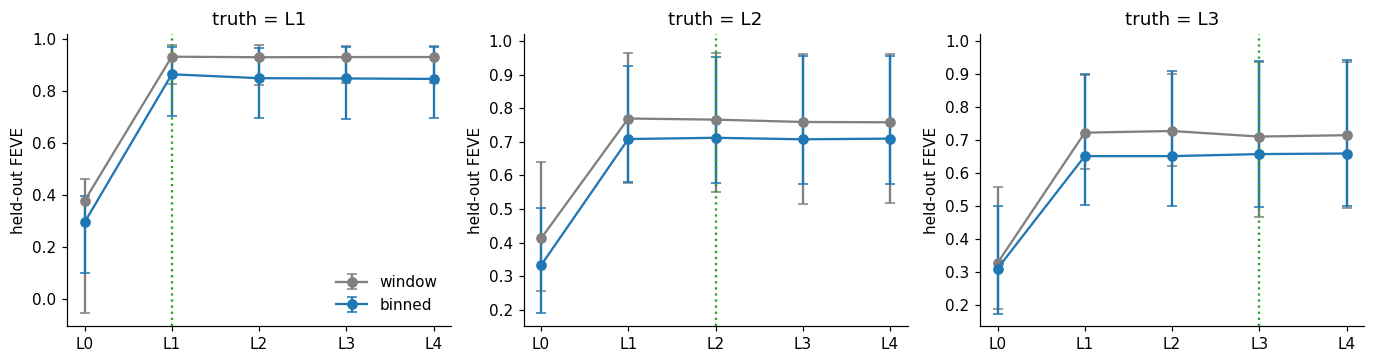

truth  seed  L* window  L* binned   gain of true rung over L1 (window / binned)
L1        1         L1         L1   +0.000 / +0.000
L2        1         L1         L1   -0.003 / +0.004
L3        1         L3         L2   -0.012 / +0.006


In [6]:
fig, axes = plt.subplots(1, len(TRUTHS), figsize=(4.2 * len(TRUTHS), 3.4), squeeze=False)
mech = ["L0", "L1", "L2", "L3", "L4"]
for ax, truth in zip(axes[0], TRUTHS):
    for kind, col in [("window", "0.5"), ("binned", "tab:blue")]:
        pts = np.array([[results[(truth, s)][kind]["point"][L] for L in mech] for s in SEEDS])
        lo = np.array([[np.percentile(results[(truth, s)][kind]["boots"][L], 2.5) for L in mech] for s in SEEDS]).mean(0)
        hi = np.array([[np.percentile(results[(truth, s)][kind]["boots"][L], 97.5) for L in mech] for s in SEEDS]).mean(0)
        mu = pts.mean(0)
        ax.errorbar(range(5), mu, yerr=[mu - lo, hi - mu], fmt="o-", color=col, capsize=3, label=kind)
    ax.axvline(ORDER[truth], ls=":", c="tab:green"); ax.set_xticks(range(5)); ax.set_xticklabels(mech)
    ax.set_title(f"truth = {truth}"); ax.set_ylabel("held-out FEVE"); ax.set_ylim(top=1.02)
axes[0][0].legend(frameon=False); plt.tight_layout(); plt.show()

print(f"{'truth':6s} {'seed':>4s} {'L* window':>10s} {'L* binned':>10s}   gain of true rung over L1 (window / binned)")
for (truth, seed), r in results.items():
    g = lambda kind: r[kind]["point"][truth] - r[kind]["point"]["L1"]
    print(f"{truth:6s} {seed:4d} {str(r['window']['dec']['L_star']):>10s} {str(r['binned']['dec']['L_star']):>10s}   {g('window'):+.3f} / {g('binned'):+.3f}")

In [7]:
def hit(r, truth):          # exact recovery (rule v2)
    return r["dec"]["L_star"] == truth
def too_deep(r, truth):
    Ls = r["dec"]["L_star"]; return Ls is not None and ORDER[Ls] > ORDER[truth]
summary = {}
for truth in TRUTHS:
    rs = [results[(truth, s)] for s in SEEDS]
    summary[truth] = {k: dict(hits=int(sum(hit(r[k], truth) for r in rs)), too_deep=int(sum(too_deep(r[k], truth) for r in rs)),
                              L_star=[r[k]["dec"]["L_star"] for r in rs]) for k in ("window", "binned")}
deep_truths = [t for t in TRUTHS if t in ("L2", "L3")]
rescue = all(summary[t]["binned"]["hits"] > summary[t]["window"]["hits"] for t in deep_truths) and \
         all(summary[t]["binned"]["too_deep"] == 0 for t in TRUTHS)
no_rescue = all(summary[t]["binned"]["hits"] <= summary[t]["window"]["hits"] for t in deep_truths)
bias = any(summary[t]["binned"]["too_deep"] > 0 for t in TRUTHS)
print(json.dumps(summary, indent=1))
print(f"\nRegistered rules -> timing rescues E1: {rescue} | no rescue: {no_rescue} | new depth bias in binned analysis: {bias}")
json.dump({"summary": summary, "rescue": rescue, "no_rescue": no_rescue, "bias_flag": bias,
           "feve": {f"{t}_s{s}": {k: {L: float(v) for L, v in results[(t, s)][k]["point"].items()} for k in ("window", "binned")}
                    for (t, s) in results}},
          open(os.path.join(RESULTS, f"E1b_synthetic_result{TAG}.json"), "w"), indent=2)

{
 "L1": {
  "window": {
   "hits": 1,
   "too_deep": 0,
   "L_star": [
    "L1"
   ]
  },
  "binned": {
   "hits": 1,
   "too_deep": 0,
   "L_star": [
    "L1"
   ]
  }
 },
 "L2": {
  "window": {
   "hits": 0,
   "too_deep": 0,
   "L_star": [
    "L1"
   ]
  },
  "binned": {
   "hits": 0,
   "too_deep": 0,
   "L_star": [
    "L1"
   ]
  }
 },
 "L3": {
  "window": {
   "hits": 1,
   "too_deep": 0,
   "L_star": [
    "L3"
   ]
  },
  "binned": {
   "hits": 0,
   "too_deep": 0,
   "L_star": [
    "L2"
   ]
  }
 }
}

Registered rules -> timing rescues E1: False | no rescue: True | new depth bias in binned analysis: False


### Result of the `laptop` run (2026-10-06; 60-neuron real wiring, one seed per truth)

| truth | L* window | L* binned | held-out FEVE window: L1 / L2 / L3 | binned: L1 / L2 / L3 |
|---|---|---|---|---|
| L1 | L1 ✓ | L1 ✓ | 0.933 / 0.931 / 0.932 | 0.865 / 0.850 / 0.849 |
| L2 | L1 | L1 | 0.769 / 0.766 / 0.759 | 0.708 / 0.712 / 0.707 |
| L3 | L3 | L2 | 0.722 / 0.727 / 0.710 | 0.651 / 0.651 / 0.657 |

**Registered verdict: no rescue.** The binned analysis has no more exact hits than the window analysis (L2: 0 vs 0; L3: 0 vs 1), and it shows no depth bias. In both analyses, the true rung gains at most +0.006 over L1.

**Two caveats that shape the next step:**

1. **The window "hit" for L3 is not evidence for L3.** L3's held-out FEVE (0.710) is *below* L1's (0.722) and L2's (0.727). The sufficiency rule reached L3 only because the uncertainty around L1 and L2 still allowed a deeper rung to add > 5%. It cannot tell "a deeper rung is needed" from "we cannot rule out that one helps". Notebook 07 adds the necessity rule, which brackets the closed level from below.
2. **The fitted true rung falls far short of the oracle.** True parameters score 1.00, while the fitted true rung scores 0.71–0.77 for truths L2 and L3. Differences of a few percent between rungs are lost in that gap, so timing information could not have shown its value here. Notebook 07 shows the gap is a problem of **identifiability, not optimization**: the fits reach the truth's training loss but not its held-out accuracy.

## 2 · What do the real response kernels say about timing?

The atlas stores one fitted kernel per (responder, stimulated) pair (Randi et al. 2023). It is a sum of terms factor · tᵖ · e^(−g t), describing how the responder follows the stimulated neuron's activity.

They are **averages: there are no per-trial kernels, so no noise ceiling**, and they cannot serve directly as E1 targets. They can still answer descriptive questions:
* How fast are the responses?
* Do pairs linked only through the peptidergic connectome respond more slowly?
* Does unc-31 (no neuropeptide release) remove slow components?

The late fraction is the share of a kernel's absolute area after 10 s. The atlas fits are taken to be in seconds, consistent with the median rate of ≈1/s, typical of calcium-indicator decay.

In [8]:
from scipy.stats import mannwhitneyu
atlas = D.open_atlas()
Kw, t = D.kernel_timecourses("wt", atlas=atlas); Ku, _ = D.kernel_timecourses("unc31", atlas=atlas)
pw, tw, lw = D.kernel_descriptors(Kw, t); pu, tu, lu = D.kernel_descriptors(Ku, t)
q = atlas.get_signal_propagation_q("wt")
sig = (q < 0.05) & np.isfinite(lw)
pep = np.nan_to_num(atlas.get_peptidergic_connectome()) > 0
direct = (np.nan_to_num(atlas.get_chemical_synapses()) > 0) | (np.nan_to_num(atlas.get_gap_junctions()) > 0)
print(f"kernels: WT {np.isfinite(Kw[..., 0]).sum()}, unc-31 {np.isfinite(Ku[..., 0]).sum()}; significant WT pairs with a kernel: {sig.sum()}")
print(f"significant pairs: time of |peak| median {np.nanmedian(tw[sig]):.1f} s (95th pct {np.nanpercentile(tw[sig], 95):.1f} s); "
      f"late fraction median {np.nanmedian(lw[sig]):.3f}")
groups = {"direct synapse": sig & direct, "peptidergic link only": sig & pep & ~direct, "neither": sig & ~pep & ~direct}
for name, sel in groups.items():
    print(f"  {name:22s} n={sel.sum():4d}  late fraction median {np.nanmedian(lw[sel]):.3f}")
p_pd = mannwhitneyu(lw[groups["peptidergic link only"]], lw[groups["direct synapse"]]).pvalue
both = sig & np.isfinite(lu)
p_wu = mannwhitneyu(lw[both], lu[both]).pvalue
print(f"peptidergic-only vs direct: p = {p_pd:.3g}")
print(f"same pairs, WT vs unc-31 (n={both.sum()}): late fraction median {np.median(lw[both]):.3f} vs {np.median(lu[both]):.3f}, p = {p_wu:.3g}")

*This version of the NeuroAtlas does not include the CAN neurons. This will be fixed soon.
kernels: WT 24075, unc-31 9228; significant WT pairs with a kernel: 978
significant pairs: time of |peak| median 0.5 s (95th pct 7.0 s); late fraction median 0.145
  direct synapse         n= 234  late fraction median 0.128
  peptidergic link only  n= 441  late fraction median 0.147
  neither                n= 303  late fraction median 0.156
peptidergic-only vs direct: p = 0.567
same pairs, WT vs unc-31 (n=227): late fraction median 0.103 vs 0.168, p = 0.0621


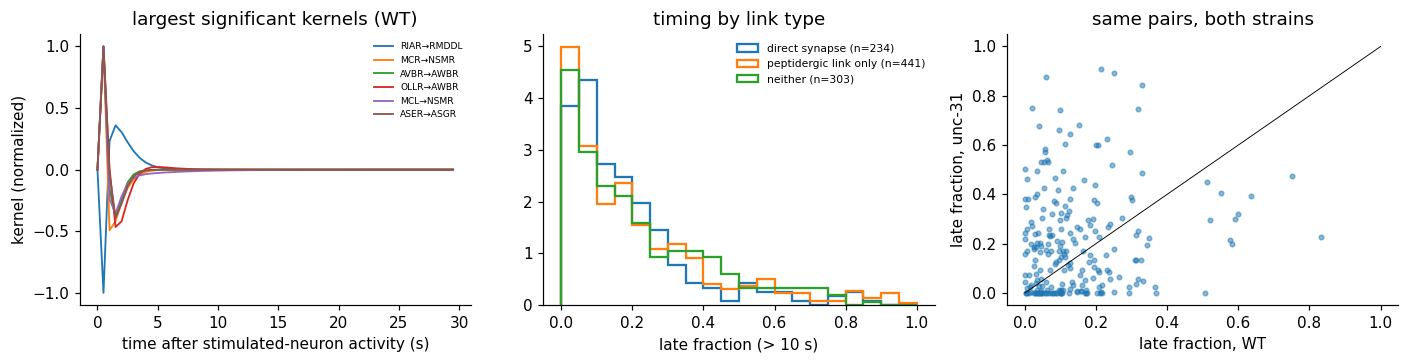

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
idx = np.argwhere(sig)[np.argsort(-np.abs(pw[sig]))[:6]]
for i, j in idx:
    k = Kw[i, j]; ax[0].plot(t, k / np.abs(k).max(), lw=1.2, label=f"{atlas.neuron_ids[j]}→{atlas.neuron_ids[i]}")
ax[0].set_xlabel("time after stimulated-neuron activity (s)"); ax[0].set_ylabel("kernel (normalized)")
ax[0].set_title("largest significant kernels (WT)"); ax[0].legend(fontsize=6, frameon=False)
bins = np.linspace(0, 1, 21)
for name, sel in groups.items():
    ax[1].hist(lw[sel], bins=bins, histtype="step", density=True, lw=1.5, label=f"{name} (n={sel.sum()})")
ax[1].set_xlabel("late fraction (> 10 s)"); ax[1].set_title("timing by link type"); ax[1].legend(fontsize=7, frameon=False)
ax[2].plot(lw[both], lu[both], ".", alpha=0.5); ax[2].plot([0, 1], [0, 1], "k-", lw=0.6)
ax[2].set_xlabel("late fraction, WT"); ax[2].set_ylabel("late fraction, unc-31"); ax[2].set_title("same pairs, both strains")
plt.tight_layout(); plt.show()

**What to look for:**

* If peptides carried a substantial slow signal, pairs linked only by the peptidergic connectome would have larger late fractions, and unc-31 would *reduce* late fractions.
* When this notebook was written, the atlas gave the following (the cell above prints the same numbers):
  * peptidergic-only links: median 0.147;
  * direct synapses: 0.128;
  * neither: 0.156;
  * unc-31 vs WT on the same pairs: 0.168 vs 0.103 (p ≈ 0.06), the opposite direction.
* So the kernel shapes show no peptidergic slow signature. This matches Notebook 03 (unc-31 effect indistinguishable from zero) and Notebook 04 (L3 adds nothing). It is descriptive evidence only: there are no trial-level kernels, and the fitted exponential forms have their own biases.

## 3 · Which real-data route for E1b?

| §1 outcome | next step |
|---|---|
| timing **rescues** E1 (binned recovers L2/L3, no depth bias) | Obtain **trial-level time courses**: the raw recordings behind Randi et al. 2023. Ask the authors or locate the deposited data. Rebuild `Dataset` with a time axis (the code supports it now) and run E1 as in Notebook 04, with `SimConfig(n_bins=10)`. The kernels above cannot replace this, because they lack trials and a noise ceiling. |
| timing **does not rescue** E1 | More resolution in time will not decide L2/L3 on this kind of experiment. The levers are different *interventions*: more unc-31 coverage, other mutants (e.g. neurotransmitter or receptor knock-outs), or spontaneous activity (Atanas et al. 2023). Treat the current E1 verdict as final for amplitude data, and move to E3 with L0/L1 as the working closed level. |
| **depth bias** in binned analysis | Fix the bias first (more restarts, longer budgets) before trusting any time-course result. |

**Outcome:** no rescue, so trial-level time courses are *not* the next step. Before choosing new interventions, though, Notebook 06 exposed a more basic limit: the fitted true rung cannot be pinned down even when it is the right model. Notebook 07 diagnoses this (identifiability), tests an ensemble estimator, and brackets the real E1 result with a necessity rule.